# Attention 训练与测试框架

这个 notebook 只负责实验流程：构造数据、选择 attention 类、训练、测试和可视化。要更换 attention 方法，优先改 `attention_cls` 和 `attention_kwargs`。

In [1]:
from pathlib import Path
import sys

import torch
from torch import nn
from d2l import torch as d2l

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'attention' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from attention import (
    ScalarAdditiveAttention,
    make_kernel_regression_data,
    make_leave_one_out_pairs,
    make_test_pairs,
)

## 1. 生成数据

In [2]:
data = make_kernel_regression_data(n_train=50, x_max=5.0, test_step=0.1, noise_std=0.5, seed=1)

x_train = data.x_train
y_train = data.y_train
x_test = data.x_test
y_truth = data.y_truth

train_keys, train_values = make_leave_one_out_pairs(x_train, y_train)
test_keys, test_values = make_test_pairs(x_train, y_train, data.n_test)

print('x_train:', x_train.shape)
print('train_keys:', train_keys.shape)
print('train_values:', train_values.shape)
print('x_test:', x_test.shape)

x_train: torch.Size([50])
train_keys: torch.Size([50, 49])
train_values: torch.Size([50, 49])
x_test: torch.Size([50])


In [3]:
def plot_kernel_reg(y_hat):
    y_hat = y_hat.reshape(-1).detach()
    d2l.plot(
        x_test,
        [y_truth, y_hat],
        'x',
        'y',
        legend=['Truth', 'Pred'],
        xlim=[0, 5],
        ylim=[-1, 5],
    )
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

## 2. 选择 attention 方法

In [4]:
attention_cls = ScalarAdditiveAttention
attention_kwargs = {
    "hidden_size": 5,
}

net = attention_cls(**attention_kwargs)
net

ScalarAdditiveAttention(
  (attention): AdditiveAttention(
    (wq): Linear(in_features=1, out_features=5, bias=True)
    (wk): Linear(in_features=1, out_features=5, bias=True)
    (wv): Linear(in_features=5, out_features=1, bias=True)
  )
)

## 3. 训练

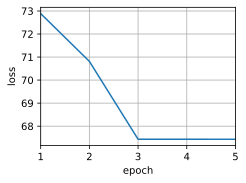

In [5]:
num_epochs = 5
lr = 0.5

loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, num_epochs])

for epoch in range(num_epochs):
    trainer.zero_grad()
    train_preds = net(x_train, train_keys, train_values)
    l = loss(train_preds, y_train)
    l.sum().backward()
    trainer.step()

    epoch_loss = float(l.sum())
    print(f'epoch {epoch + 1}, loss {epoch_loss:.6f}')
    animator.add(epoch + 1, epoch_loss)

## 4. 测试预测

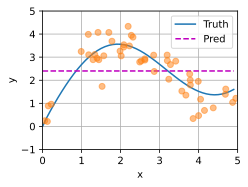

In [6]:
with torch.no_grad():
    y_hat = net(x_test, test_keys, test_values)

plot_kernel_reg(y_hat)

## 5. 查看 attention 权重

torch.Size([50, 50])


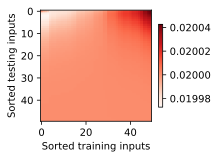

In [7]:
print(net.attention_weights.shape)
if net.attention_weights is not None:
    d2l.show_heatmaps(
        net.attention_weights.unsqueeze(0).unsqueeze(0),
        xlabel='Sorted training inputs',
        ylabel='Sorted testing inputs',
    )

## 更换 attention 方法

如果新 attention 也实现 `forward(queries, keys, values)` 并把权重存到 `self.attention_weights`，这个训练/测试流程不用改。

例如添加新类后，只需要改选择模型的 cell：

```python
from attention import MyAttention
attention_cls = MyAttention
attention_kwargs = {...}
net = attention_cls(**attention_kwargs)
```